# Практическая работа 2
***

## Задача 1. Калибровка акселерометра и гироскопа

**Задача:**
Написать программу для калибровки MPU6050 (определение смещений нуля и масштабных коэффициентов).

**Требования:**

Записать 1000 измерений акселерометра и гироскопа в покое.

Вычислить средние значения (калибровочные смещения).

Применить калибровку к новым измерениям.

In [ ]:
from machine import Pin, I2C
from time import sleep_ms
import math

MPU_ADDR = 0x68

def write_reg(reg, val):
    i2c.writeto_mem(MPU_ADDR, reg, bytes([val]))

def read_raw_data(reg):
    high, low = i2c.readfrom_mem(MPU_ADDR, reg, 2)
    value = (high << 8) | low
    if value > 32767:
        value -= 65536
    return value

def read_accel():
    ax = read_raw_data(0x3B)
    ay = read_raw_data(0x3D)
    az = read_raw_data(0x3F)
    ax /= 16384.0
    ay /= 16384.0
    az /= 16384.0
    return ax, ay, az

def read_gyro():
    gx = read_raw_data(0x43)
    gy = read_raw_data(0x45)
    gz = read_raw_data(0x47)
    gx /= 131.0
    gy /= 131.0
    gz /= 131.0
    return gx, gy, gz

i2c = I2C(0, scl=Pin(22), sda=Pin(21), freq=400000)

write_reg(0x6B, 0)

print("Старт калибровки...")
sleep_ms(1000)

N = 1000

sum_ax = sum_ay = sum_az = 0
sum_gx = sum_gy = sum_gz = 0

for _ in range(N):
    ax, ay, az = read_accel()
    gx, gy, gz = read_gyro()

    sum_ax += ax
    sum_ay += ay
    sum_az += az

    sum_gx += gx
    sum_gy += gy
    sum_gz += gz

    sleep_ms(2)

acc_bias = (
    sum_ax / N,
    sum_ay / N,
    sum_az / N
)

gyro_bias = (
    sum_gx / N,
    sum_gy / N,
    sum_gz / N
)

print("\nКалибровка завершена")
print("Смещения акселерометра:", acc_bias)
print("Смещения гироскопа:", gyro_bias)

sleep_ms(500)

while True:
    ax, ay, az = read_accel()
    gx, gy, gz = read_gyro()

    ax_c = ax - acc_bias[0]
    ay_c = ay - acc_bias[1]
    az_c = az - acc_bias[2]

    gx_c = gx - gyro_bias[0]
    gy_c = gy - gyro_bias[1]
    gz_c = gz - gyro_bias[2]

    print("ACC calib:", ax_c, ay_c, az_c)
    print("GYRO calib:", gx_c, gy_c, gz_c)
    print("-------------------------")

    sleep_ms(200)

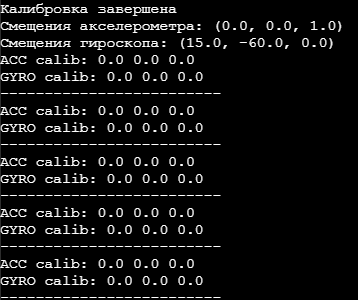

## Задача 2. Фильтрация данных с IMU (комплементарный фильтр)

**Задача:**

Реализовать комплементарный фильтр для объединения данных акселерометра и гироскопа.

**Требования:**

Получить углы наклона по акселерометру (atan2).

Интегрировать угловую скорость с гироскопа.

Смешать данные с коэффициентом alpha = 0.98.
Пример вывода:

`Pitch: 12.5°, Roll: -3.2°`

In [ ]:
from machine import Pin, I2C
from time import ticks_ms, ticks_diff, sleep_ms
from math import atan2, degrees

MPU_ADDR = 0x68

def write_reg(reg, val):
    i2c.writeto_mem(MPU_ADDR, reg, bytes([val]))

def read_raw_data(reg):
    high, low = i2c.readfrom_mem(MPU_ADDR, reg, 2)
    value = (high << 8) | low
    if value > 32767:
        value -= 65536
    return value

def read_accel():
    ax = read_raw_data(0x3B) / 16384.0
    ay = read_raw_data(0x3D) / 16384.0
    az = read_raw_data(0x3F) / 16384.0
    return ax, ay, az

def read_gyro():
    gx = read_raw_data(0x43) / 131.0
    gy = read_raw_data(0x45) / 131.0
    gz = read_raw_data(0x47) / 131.0
    return gx, gy, gz

i2c = I2C(0, scl=Pin(22), sda=Pin(21), freq=400000)
write_reg(0x6B, 0)

alpha = 0.98

pitch = 0
roll = 0

prev_time = ticks_ms()

while True:
    now = ticks_ms()
    dt = ticks_diff(now, prev_time) / 1000.0
    prev_time = now

    ax, ay, az = read_accel()
    gx, gy, gz = read_gyro()

    roll_acc  = degrees(atan2(ay, az))
    pitch_acc = degrees(atan2(-ax, (ay*ay + az*az)**0.5))

    pitch_gyro = pitch + gy * dt
    roll_gyro  = roll + gx * dt

    pitch = alpha * pitch_gyro + (1 - alpha) * pitch_acc
    roll  = alpha * roll_gyro  + (1 - alpha) * roll_acc

    print("Pitch: {:.2f}°,  Roll: {:.2f}°".format(pitch, roll))

    sleep_ms(20)

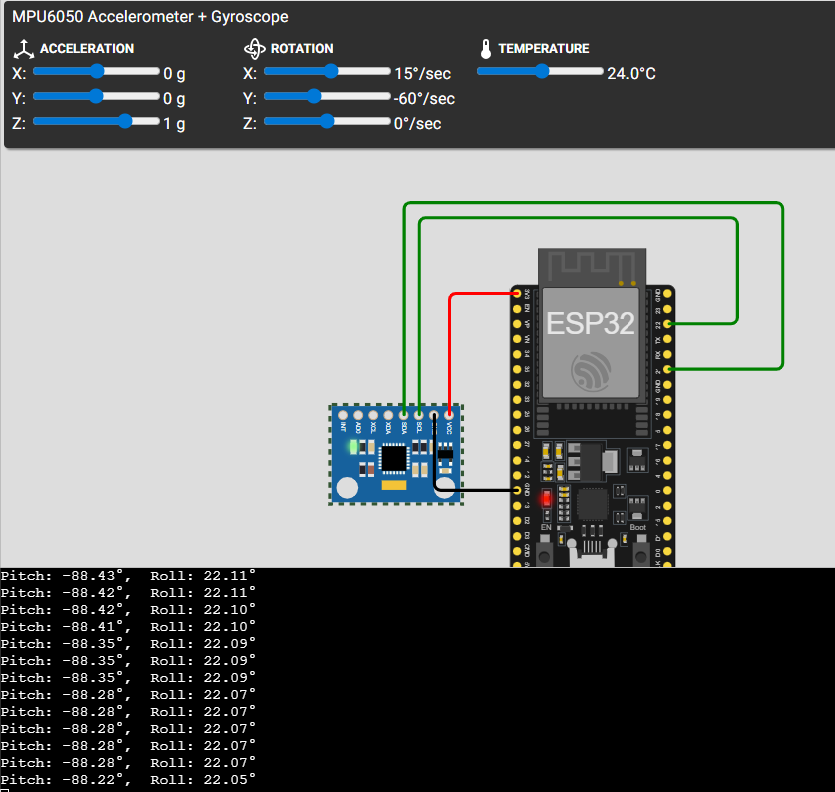

## Задача 3. Определение положения робота методом "dead reckoning"

**Задача:**

Смоделировать движение робота вперед на 1 метр с использованием данных акселерометра.

**Требования:**

Дважды проинтегрировать ускорение для получения положения.

Учесть шумы (добавить случайные колебания ±0.1 м/с²).

Вывести график пути в Wokwi (через `print`).

In [ ]:
from machine import Pin, I2C
from time import ticks_ms, ticks_diff, sleep_ms
import random

MPU_ADDR = 0x68

def write_reg(reg, val):
    i2c.writeto_mem(MPU_ADDR, reg, bytes([val]))

def read_raw(reg):
    h, l = i2c.readfrom_mem(MPU_ADDR, reg, 2)
    v = (h << 8) | l
    if v > 32767:
        v -= 65536
    return v

def read_accel():
    ax = read_raw(0x3B) / 16384.0
    ay = read_raw(0x3D) / 16384.0
    az = read_raw(0x3F) / 16384.0
    return ax, ay, az

i2c = I2C(0, scl=Pin(22), sda=Pin(21), freq=400000)
write_reg(0x6B, 0)

print("Начало симуляции...")

target_distance = 1.0
noise_amp = 0.1
velocity = 0.0
position = 0.0
positions = []

prev_t = ticks_ms()

while position < target_distance:

    now = ticks_ms()
    dt = ticks_diff(now, prev_t) / 1000.0
    prev_t = now

    ax, ay, az = read_accel()

    acc = ax * 9.81

    acc += random.uniform(-noise_amp, noise_amp)

    velocity += acc * dt

    position += velocity * dt

    positions.append(position)

    print("a={:+.2f}  v={:+.2f}  x={:+.3f}".format(acc, velocity, position))

    sleep_ms(20)


print("\n=== Моделирование завершено ===")
print("Пройденное расстояние: {:.3f} м".format(position))
print("Количество шагов:", len(positions))
print("\nГрафик пути:")
print("--------------------------------")

scale = 50

for p in positions:
    print("." * int(p * scale) + "*")

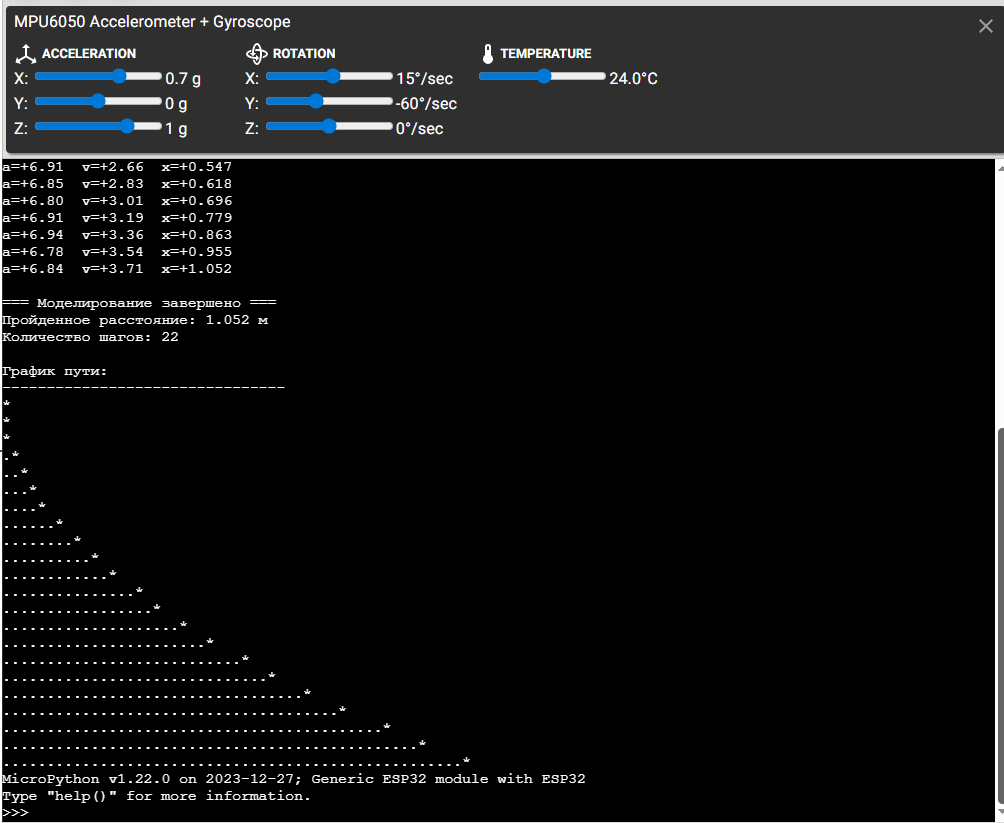

## Задача 4. Управление шаговым двигателем по заданному углу

**Задача:**

Написать программу, которая поворачивает шаговый двигатель на заданный угол (например, 90°).

**Требования:**

Использовать драйвер L298N и микрошаговый режим.

Рассчитать количество шагов для нужного угла (например, 200 шагов = 360°).
Формула:

`steps_needed = (angle / 360) * 200`

In [ ]:
from machine import Pin
from time import sleep_us, sleep

IN1 = Pin(16, Pin.OUT)
IN2 = Pin(17, Pin.OUT)
IN3 = Pin(18, Pin.OUT)
IN4 = Pin(19, Pin.OUT)

SEQ = [
    (1, 0, 1, 0),
    (0, 1, 1, 0),
    (0, 1, 0, 1),
    (1, 0, 0, 1),
]

STEP_COUNT = len(SEQ)
STEP_INDEX = 0

MICROSTEP = 1
STEPS_PER_REV = 200

def apply_phase(phase):
    IN1.value(phase[0])
    IN2.value(phase[1])
    IN3.value(phase[2])
    IN4.value(phase[3])

def step_motor(steps, direction=1, delay_us=2000):
    global STEP_INDEX

    direction = 1 if direction > 0 else -1

    for _ in range(steps):
        STEP_INDEX = (STEP_INDEX + direction) % STEP_COUNT
        apply_phase(SEQ[STEP_INDEX])
        sleep_us(delay_us)

def angle_to_steps(angle):
    return int((angle / 360) * STEPS_PER_REV * MICROSTEP)

#Пример использования
angle = 90
steps = angle_to_steps(angle)

print("Поворот на", angle, "°, шагов:", steps)
step_motor(steps, direction=1)

## Задача 5. Разворот робота на кватернионах

**Задача:**
Реализовать разворот робота на 180° с использованием кватернионов.

**Требования:**

Инициализировать кватернион.

Обновлять его на основе данных гироскопа.

Остановить моторы при достижении угла 180°.
Пример:

In [ ]:
while yaw < 3.14:  # 180° в радианах
    q = update_quaternion(q, gx, gy, gz, dt)
    yaw = quaternion_to_euler(q)[2]

In [ ]:
from machine import Pin, I2C
from time import sleep
import math

IN1 = Pin(16, Pin.OUT)
IN2 = Pin(17, Pin.OUT)
IN3 = Pin(18, Pin.OUT)
IN4 = Pin(19, Pin.OUT)

SEQ = [
    (1, 0, 1, 0),
    (0, 1, 1, 0),
    (0, 1, 0, 1),
    (1, 0, 0, 1),
]

STEP_INDEX = 0

def apply_phase(phase):
    IN1.value(phase[0])
    IN2.value(phase[1])
    IN3.value(phase[2])
    IN4.value(phase[3])

def step_motor(direction=1):
    global STEP_INDEX
    direction = 1 if direction > 0 else -1
    STEP_INDEX = (STEP_INDEX + direction) % 4
    apply_phase(SEQ[STEP_INDEX])

i2c = I2C(0, scl=Pin(22), sda=Pin(21))
MPU = 0x68

def mpu_read():
    data = i2c.readfrom_mem(MPU, 0x43, 6)
    gx = int.from_bytes(data[0:2], 'big', signed=True) / 131.0
    gy = int.from_bytes(data[2:4], 'big', signed=True) / 131.0
    gz = int.from_bytes(data[4:6], 'big', signed=True) / 131.0
    return gx, gy, gz

def normalize(q):
    norm = math.sqrt(sum(i*i for i in q))
    return tuple(i / norm for i in q)

def update_quaternion(q, gx, gy, gz, dt):
    gx = math.radians(gx)
    gy = math.radians(gy)
    gz = math.radians(gz)

    qw, qx, qy, qz = q

    dq_w = 0.5 * (-qx*gx - qy*gy - qz*gz)
    dq_x = 0.5 * (qw*gx + qy*gz - qz*gy)
    dq_y = 0.5 * (qw*gy - qx*gz + qz*gx)
    dq_z = 0.5 * (qw*gz + qx*gy - qy*gx)

    qw += dq_w * dt
    qx += dq_x * dt
    qy += dq_y * dt
    qz += dq_z * dt

    return normalize((qw, qx, qy, qz))

def quaternion_to_euler(q):
    w, x, y, z = q

    # yaw (Z)
    yaw = math.atan2(2*(w*z + x*y), 1 - 2*(y*y + z*z))

    # pitch (Y)
    pitch = math.asin(2*(w*y - z*x))

    # roll (X)
    roll = math.atan2(2*(w*x + y*z), 1 - 2*(x*x + y*y))

    return roll, pitch, yaw

q = (1, 0, 0, 0)
yaw = 0
dt = 0.01

print("Начало разворота на 180°...")

while abs(yaw) < math.pi:
    gx, gy, gz = mpu_read()

    q = update_quaternion(q, gx, gy, gz, dt)

    roll, pitch, yaw = quaternion_to_euler(q)

    step_motor(direction=1)

    print("yaw =", yaw)

    sleep(dt)

apply_phase((0,0,0,0))
print("Разворот завершён")

## Задача 6. ПИД-регулятор для стабилизации угла наклона

**Задача:**
Написать ПИД-регулятор, который удерживает робота в горизонтальном положении.

**Требования:**

Использовать фильтрованный угол наклона.

Регулировать скорость моторов для компенсации наклона.
Формула PID:

In [ ]:
output = Kp * error + Ki * integral + Kd * derivative

In [ ]:
from machine import Pin, I2C
from time import sleep, ticks_ms, ticks_diff
import math

L_IN1 = Pin(16, Pin.OUT)
L_IN2 = Pin(17, Pin.OUT)

R_IN1 = Pin(18, Pin.OUT)
R_IN2 = Pin(19, Pin.OUT)

def motor_left(speed):
    if speed > 0:
        L_IN1.value(1)
        L_IN2.value(0)
    elif speed < 0:
        L_IN1.value(0)
        L_IN2.value(1)
    else:
        L_IN1.value(0)
        L_IN2.value(0)

def motor_right(speed):
    if speed > 0:
        R_IN1.value(1)
        R_IN2.value(0)
    elif speed < 0:
        R_IN1.value(0)
        R_IN2.value(1)
    else:
        R_IN1.value(0)
        R_IN2.value(0)

i2c = I2C(0, scl=Pin(22), sda=Pin(21))
MPU = 0x68

def mpu_read():
    acc = i2c.readfrom_mem(MPU, 0x3B, 6)
    gyro = i2c.readfrom_mem(MPU, 0x43, 6)

    ax = int.from_bytes(acc[0:2], 'big', signed=True) / 16384
    ay = int.from_bytes(acc[2:4], 'big', signed=True) / 16384
    az = int.from_bytes(acc[4:6], 'big', signed=True) / 16384

    gx = int.from_bytes(gyro[0:2], 'big', signed=True) / 131
    gy = int.from_bytes(gyro[2:4], 'big', signed=True) / 131
    gz = int.from_bytes(gyro[4:6], 'big', signed=True) / 131

    return ax, ay, az, gx, gy, gz

alpha = 0.98
angle = 0

Kp = 35
Ki = 0.0
Kd = 2.0

integral = 0
prev_error = 0

last_time = ticks_ms()

while True:
    now = ticks_ms()
    dt = ticks_diff(now, last_time) / 1000
    last_time = now

    ax, ay, az, gx, gy, gz = mpu_read()

    acc_angle = math.degrees(math.atan2(ax, math.sqrt(ay*ay + az*az)))

    angle = alpha * (angle + gy * dt) + (1 - alpha) * acc_angle

    target = 0
    error = target - angle

    global integral
    integral += error * dt

    derivative = (error - prev_error) / dt if dt > 0 else 0
    prev_error = error

    pid = Kp * error + Ki * integral + Kd * derivative

    pid = max(min(pid, 100), -100)

    motor_left(pid)
    motor_right(pid)

    print("angle={:.2f}°, pid={:.2f}".format(angle, pid))

    sleep(0.01)

## Задача 7. Симуляция движения по квадрату в Wokwi

**Задача:**
Запрограммировать робота на движение по квадрату (1 метр сторона).

**Требования:**

Использовать шаговые двигатели.

Контролировать пройденное расстояние через энкодеры или время.

Развернуться на 90° после каждого отрезка.

In [ ]:
from machine import Pin
import time

dir1 = Pin(17, Pin.OUT)
step1 = Pin(16, Pin.OUT)

dir2 = Pin(19, Pin.OUT)
step2 = Pin(18, Pin.OUT)

STEPS_PER_METER = 960
TURN_STEPS = 112
STEP_DELAY = 0.0015

def forward(steps):
    dir1.value(1)
    dir2.value(1)
    for _ in range(steps):
        step1.value(1)
        step2.value(1)
        time.sleep(STEP_DELAY)
        step1.value(0)
        step2.value(0)
        time.sleep(STEP_DELAY)

def turn_right_90():
    dir1.value(0)
    dir2.value(1)
    for _ in range(TURN_STEPS):
        step1.value(1)
        step2.value(1)
        time.sleep(STEP_DELAY)
        step1.value(0)
        step2.value(0)
        time.sleep(STEP_DELAY)

print("Старт")

for i in range(4):
    print("Сторона ", i + 1)
    forward(STEPS_PER_METER)
    turn_right_90()

print("Квадрат завершён")

## Задача 8. Сравнение углов Эйлера и кватернионов

**Задача:**

Сравнить точность углов Эйлера и кватернионов при резких поворотах.

**Требования:**

Запустить симуляцию с искусственными данными гироскопа.

Построить графики ошибок для обоих методов.

Объяснить, в каких случаях лучше использовать кватернионы.
***

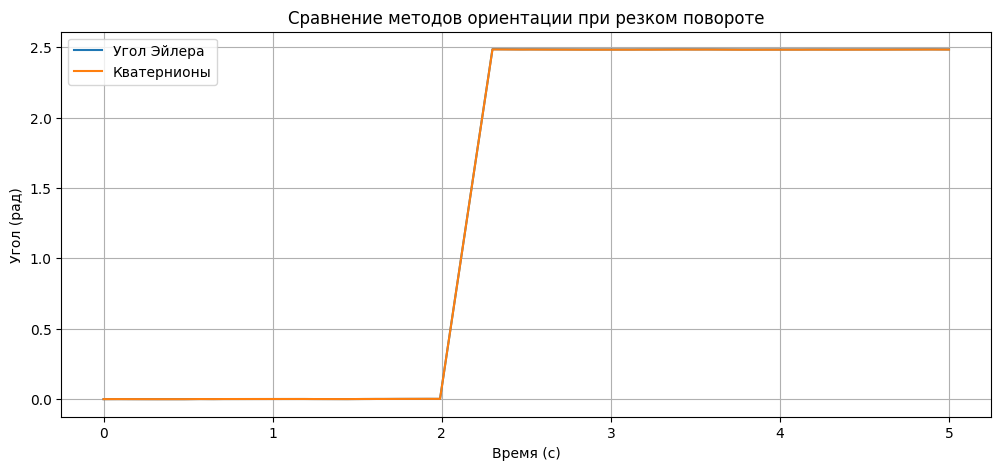

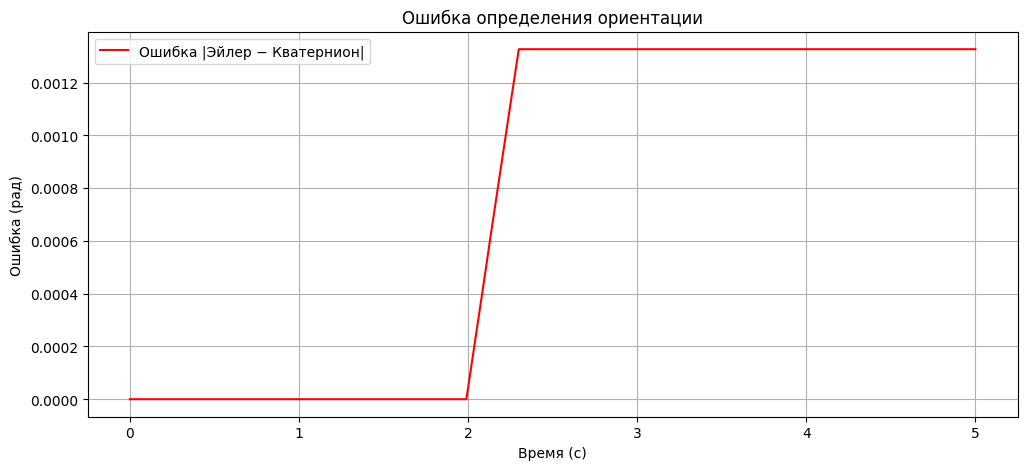

In [3]:
import math
import random
import matplotlib.pyplot as plt

def normalize(q):
    n = math.sqrt(sum(i * i for i in q))
    return [i / n for i in q]

def quat_update(q, gx, gy, gz, dt):
    wx, wy, wz = gx * dt / 2, gy * dt / 2, gz * dt / 2

    dq = [1, wx, wy, wz]
    w1, x1, y1, z1 = dq
    w2, x2, y2, z2 = q

    # умножение dq * q
    q_new = [
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ]

    return normalize(q_new)

def quat_to_euler(q):
    w, x, y, z = q

    # yaw (Z)
    yaw = math.atan2(2*(w*z + x*y), 1 - 2*(y*y + z*z))
    # pitch (Y)
    pitch = math.asin(max(-1, min(1, 2*(w*y - z*x))))
    # roll (X)
    roll = math.atan2(2*(w*x + y*z), 1 - 2*(x*x + y*y))

    return roll, pitch, yaw

dt = 0.01
t_max = 5.0

times = []
gyro_z_data = []

t = 0.0
while t < t_max:
    if t < 2.0:
        gz = 0.0 + random.uniform(-0.02, 0.02)
    elif 2.0 <= t < 2.3:
        gz = 8.0 + random.uniform(-0.1, 0.1)
    else:
        gz = 0.0 + random.uniform(-0.02, 0.02)

    gyro_z_data.append(gz)
    times.append(t)
    t += dt

yaw_euler = []
yaw_quat = []
euler_angle = 0.0

q = [1, 0, 0, 0]

for gz in gyro_z_data:
    euler_angle += gz * dt

    q = quat_update(q, 0, 0, gz, dt)
    _, _, yaw_q = quat_to_euler(q)

    yaw_euler.append(euler_angle)
    yaw_quat.append(yaw_q)


error = [abs(a - b) for a, b in zip(yaw_euler, yaw_quat)]


plt.figure(figsize=(12, 5))
plt.plot(times, yaw_euler, label="Углы Эйлера")
plt.plot(times, yaw_quat, label="Кватернионы")
plt.title("Сравнение методов ориентации при резком повороте")
plt.xlabel("Время (с)")
plt.ylabel("Угол (рад)")
plt.grid()
plt.legend()

plt.figure(figsize=(12, 5))
plt.plot(times, error, label="Ошибка |Эйлер − Кватернион|", color="red")
plt.title("Ошибка определения ориентации")
plt.xlabel("Время (с)")
plt.ylabel("Ошибка (рад)")
plt.grid()
plt.legend()

plt.show()


На графике видно «пик» ошибки в момент резкого вращения.

А кватернионы почти не дают накопленных ошибок — благодаря нормализации.

Кватернионы используют, когда:
*   есть резкие повороты
*   ориентация может изменяться на большие углы
*   важна стабильность и отсутствие дрейфа
*   робот/дрон использует IMU для стабилизации

А углы Эйлера подходят только для медленных движений или визуализации.

**Критерии оценки:**

Корректность математических расчетов.
Оптимальность кода (минимальные задержки, эффективность).
Визуализация данных (вывод в консоль Wokwi).
Анализ результатов (например, сравнение дрейфа в разных методах).

Совет: Для задач с графиками можно использовать print в формате CSV и построить графики в Python или Excel.

